# 网格天气现象电码系统 — 集成测试 Notebook

**依据**：QX/T 740-2024  
**版本**：v1.0.0  

本 Notebook 提供四个层级的验证：
1. 环境与导入检查
2. Plugin 类接口单元测试（纯内存，无需数据文件）
3. 算法逻辑集成测试（mock 数据）
4. pytest 全量测试报告

## 0. 路径设置（首次运行必须执行）

In [1]:
import sys, os

# 将项目根目录加入 sys.path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'项目根目录: {PROJECT_ROOT}')
print(f'Python 版本: {sys.version}')

项目根目录: D:\aaaa\weather_phenom_grid_12h
Python 版本: 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]


## 1. 环境与导入检查

In [3]:
import importlib

required_packages = ['numpy', 'xarray', 'netCDF4','meteva', 'numexpr']

print('=== 必要依赖 ===')
for pkg in required_packages:
    try:
        m = importlib.import_module(pkg)
        ver = getattr(m, '__version__', 'unknown')
        print(f'  ✓ {pkg} {ver}')
    except ImportError:
        print(f'  ✗ {pkg} 未安装！请运行: pip install {pkg}')

print('\n=== 可选依赖 ===')
for pkg in optional_packages:
    try:
        m = importlib.import_module(pkg)
        ver = getattr(m, '__version__', 'unknown')
        print(f'  ✓ {pkg} {ver}')
    except ImportError:
        print(f'  - {pkg} 未安装（可选）')

=== 必要依赖 ===
  ✓ numpy 2.2.6
  ✓ xarray 2025.6.1
  ✓ netCDF4 1.7.4
  ✓ meteva 1.9.5.1
  ✓ numexpr 2.14.1

=== 可选依赖 ===
  ✓ meteva 1.9.5.1
  ✓ numexpr 2.14.1


In [4]:
# 导入算法模块
from src import (
    __version__,
    DIA_WeatherPhenomIdentifier,
    DIA_WeatherPhenomSelector,
    DIA_WeatherPhenomLogicJudger,
    DIA_WeatherPhenomEncoder,
)
from src.encoder import decode

print(f'系统版本: v{__version__}')
print('所有 Plugin 类导入成功 ✓')

# 验证 Plugin 接口合规性
plugins = [
    DIA_WeatherPhenomIdentifier(),
    DIA_WeatherPhenomSelector(),
    DIA_WeatherPhenomLogicJudger(),
    DIA_WeatherPhenomEncoder(),
]
for p in plugins:
    assert hasattr(p, '__init__'), f'{p.__class__.__name__} 缺少 __init__'
    assert hasattr(p, 'process') and callable(p.process), f'{p.__class__.__name__} 缺少 process()'
    print(f'  ✓ {p.__class__.__name__}  __init__ + process() 接口合规')

系统版本: v1.0.0
所有 Plugin 类导入成功 ✓
  ✓ DIA_WeatherPhenomIdentifier  __init__ + process() 接口合规
  ✓ DIA_WeatherPhenomSelector  __init__ + process() 接口合规
  ✓ DIA_WeatherPhenomLogicJudger  __init__ + process() 接口合规
  ✓ DIA_WeatherPhenomEncoder  __init__ + process() 接口合规


## 2. Plugin 类单元测试（mock 数据，无需实际 NC 文件）

In [5]:
import numpy as np

# ─── 构造 mock 数据 ─────────────────────────────────────────
nlat, nlon, n_steps = 10, 12, 4
rng = np.random.default_rng(seed=42)

mock_data = {
    'R03':      rng.uniform(0, 20, (n_steps, nlat, nlon)).astype(np.float32),
    'PTYPE03':  rng.choice([1, 2, 3, 4], (n_steps, nlat, nlon)).astype(np.float32),
    'TCC':      rng.uniform(0, 100, (n_steps, nlat, nlon)).astype(np.float32),
    'FOG':      rng.choice([0, 1, 2, 3, 4], (n_steps, nlat, nlon)).astype(np.float32),
    'HAZE':     rng.choice([0, 1, 2, 3], (n_steps, nlat, nlon)).astype(np.float32),
    'SAND':     rng.choice([0, 1, 2, 3], (n_steps, nlat, nlon)).astype(np.float32),
    'THUNDER':  rng.choice([0, 1], (n_steps, nlat, nlon)).astype(np.float32),
    'HAIL':     rng.choice([0, 1], (n_steps, nlat, nlon)).astype(np.float32),
}

print(f'mock 数据形状: [{n_steps}, {nlat}, {nlon}]')
print(f'变量列表: {list(mock_data.keys())}')

mock 数据形状: [4, 10, 12]
变量列表: ['R03', 'PTYPE03', 'TCC', 'FOG', 'HAZE', 'SAND', 'THUNDER', 'HAIL']


In [6]:
# ─── Step 2: 判识 ──────────────────────────────────────────
identifier = DIA_WeatherPhenomIdentifier()
occur = identifier.process(mock_data)

print(f'判识输出天气现象数: {len(occur)}')
assert len(occur) == 31, f'期望31种天气现象，实际 {len(occur)} 种'

sample_code = list(occur.keys())[0]
sample_val  = occur[sample_code]
assert '12h' in sample_val and 'fine' in sample_val, '判识输出格式错误'
assert sample_val['12h'].shape == (nlat, nlon),  f'12h形状错误: {sample_val["12h"].shape}'
assert sample_val['fine'].shape == (n_steps, nlat, nlon), f'fine形状错误'

print(f'  ✓ 输出31种天气现象，形状正确')

判识输出天气现象数: 31
  ✓ 输出31种天气现象，形状正确


In [7]:
# ─── Step 3: 选取 ──────────────────────────────────────────
selector = DIA_WeatherPhenomSelector()
idx_A, idx_B = selector.process(occur)

assert idx_A.shape == (nlat, nlon), f'idx_A形状错误: {idx_A.shape}'
assert idx_B.shape == (nlat, nlon), f'idx_B形状错误: {idx_B.shape}'
assert idx_A.dtype == np.int8, f'idx_A dtype应为int8，实际: {idx_A.dtype}'

has_b_count = (idx_B != -1).sum()
print(f'  ✓ idx_A/B形状: {idx_A.shape}，dtype: int8')
print(f'  有B现象的格点数: {has_b_count} / {nlat*nlon} ({has_b_count/(nlat*nlon)*100:.1f}%)')

  ✓ idx_A/B形状: (10, 12)，dtype: int8
  有B现象的格点数: 115 / 120 (95.8%)


In [8]:
# ─── Step 4: 逻辑关系 ───────────────────────────────────────
judger = DIA_WeatherPhenomLogicJudger()
logic, idx_fa, idx_fb = judger.process(idx_A, idx_B, occur)

assert logic.shape == (nlat, nlon),   f'logic形状错误'
assert idx_fa.shape == (nlat, nlon),  f'idx_fa形状错误'
assert idx_fb.shape == (nlat, nlon),  f'idx_fb形状错误'
assert set(np.unique(logic)).issubset({0, 1, 2, 3}), f'逻辑值超出范围: {np.unique(logic)}'

logic_counts = {k: int((logic == k).sum()) for k in range(4)}
logic_names  = {0: '单一', 1: '转', 2: '间', 3: '伴有'}
print('  ✓ 逻辑关系判断完成')
for k, cnt in logic_counts.items():
    print(f'    {logic_names[k]:4s}: {cnt:5d} 格点 ({cnt/(nlat*nlon)*100:.1f}%)')

  ✓ 逻辑关系判断完成
    单一  :     5 格点 (4.2%)
    转   :   115 格点 (95.8%)
    间   :     0 格点 (0.0%)
    伴有  :     0 格点 (0.0%)


In [9]:
# ─── Step 5: 编码 ───────────────────────────────────────────
encoder = DIA_WeatherPhenomEncoder()
result = encoder.process(idx_fa, idx_fb, logic)

assert result.shape == (nlat, nlon),  f'result形状错误'
assert result.dtype == np.int32,      f'result dtype应为int32，实际: {result.dtype}'

unique_codes = np.unique(result)
print(f'  ✓ 编码完成，形状: {result.shape}，dtype: int32')
print(f'  出现的电码数: {len(unique_codes)}')
print(f'  部分电码示例:')
for code in unique_codes[:5]:
    info = decode(int(code))
    print(f'    {code:05d} → {info["预报表述"]}')

  ✓ 编码完成，形状: (10, 12)，dtype: int32
  出现的电码数: 39
  部分电码示例:
    00505 → 雷阵雨并伴有冰雹
    03737 → 特大暴雪
    10105 → 多云转雷阵雨并伴有冰雹
    10506 → 雷阵雨并伴有冰雹转雨夹雪
    10516 → 雷阵雨并伴有冰雹转大雪


## 3. 编码/解码标准示例验证

In [10]:
from resource.weather_config import STANDARD_EXAMPLES

print('=== 编码/解码标准示例验证 ===')
all_pass = True
for ex in STANDARD_EXAMPLES:
    result_dec = decode(int(ex['电码']))
    ok = result_dec['预报表述'] == ex['表述']
    status = '✓' if ok else f'✗ (得到: {result_dec["预报表述"]}，期望: {ex["表述"]})'  
    print(f'  {ex["电码"]} → {result_dec["预报表述"]:16s}  {status}')
    if not ok:
        all_pass = False

print()
print(f'结果: {"全部通过 ✓" if all_pass else "存在失败项 ✗"}')

=== 编码/解码标准示例验证 ===
  10207 → 阴转小雨              ✓
  20001 → 晴间多云              ✓
  35661 → 中度霾伴有轻雾           ✓
  00101 → 多云                ✓

结果: 全部通过 ✓


## 4. pytest 全量测试（运行 test/ 目录）

In [11]:
import subprocess

pytest_result = subprocess.run(
    [sys.executable, '-m', 'pytest', 'test/', '-v', '--tb=short', '--no-header'],
    capture_output=True,
    text=True,
    cwd=PROJECT_ROOT,
)

print(pytest_result.stdout)
if pytest_result.returncode != 0:
    print('STDERR:', pytest_result.stderr)
    print(f'\npytest 退出码: {pytest_result.returncode}')
else:
    print('\n所有测试通过 ✓')

============================= test session starts =============================
collecting ... collected 58 items

test/test_data_loader.py::test_segment_fh_seg1 PASSED                    [  1%]
test/test_data_loader.py::test_segment_fh_seg7 PASSED                    [  3%]
test/test_data_loader.py::test_segment_fh_seg20 PASSED                   [  5%]
test/test_data_loader.py::test_segment_fh_boundary PASSED                [  6%]
test/test_data_loader.py::test_load_segment_basic PASSED                 [  8%]
test/test_data_loader.py::test_load_segment_72h_fill_zero PASSED         [ 10%]
test/test_data_loader.py::test_load_segment_all_missing PASSED           [ 12%]
test/test_encoder.py::test_encode_single_duoyun PASSED                   [ 13%]
test/test_encoder.py::test_encode_single_qing PASSED                     [ 15%]
test/test_encoder.py::test_encode_single_baoyu PASSED                    [ 17%]
test/test_encoder.py::test_encode_zhuan PASSED                           [ 18%]
test/

## 5. 电码分布可视化（可选，需 matplotlib）

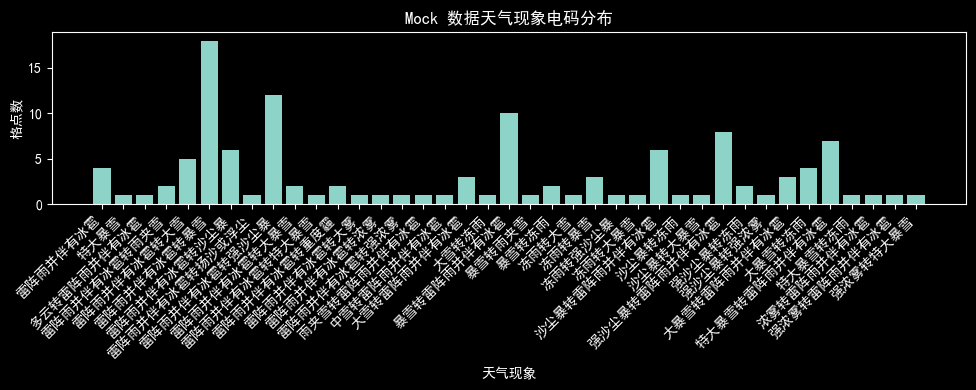

In [12]:
try:
    import matplotlib.pyplot as plt
    from src.encoder import decode
    
    unique_codes, counts = np.unique(result, return_counts=True)
    labels = [decode(int(c))['预报表述'] for c in unique_codes]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(counts)), counts, tick_label=labels)
    ax.set_title('Mock 数据天气现象电码分布')
    ax.set_xlabel('天气现象')
    ax.set_ylabel('格点数')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib 未安装，跳过可视化（pip install matplotlib）')